<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-06-04 16:46:53--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  42.7MB/s    in 4.8s    

2026-06-04 16:46:58 (41.7 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]



#### Install the required libraries and import them


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 123.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 168.3 MB/s eta 0:00:00


In [3]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 138.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 133.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 180.8 MB/s eta 0:00:00


In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [5]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [6]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [7]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


In [51]:
## Write your code here
QUERY = """
SELECT ResponseId,  CompTotal FROM main where CompTotal is not null
Group by CompTotal
"""
df = pd.read_sql_query(QUERY, conn)
print(df.head())

   ResponseId  CompTotal
0         698        0.0
1        3891        1.0
2       25201        2.0
3       20630        3.0
4       15321        4.0


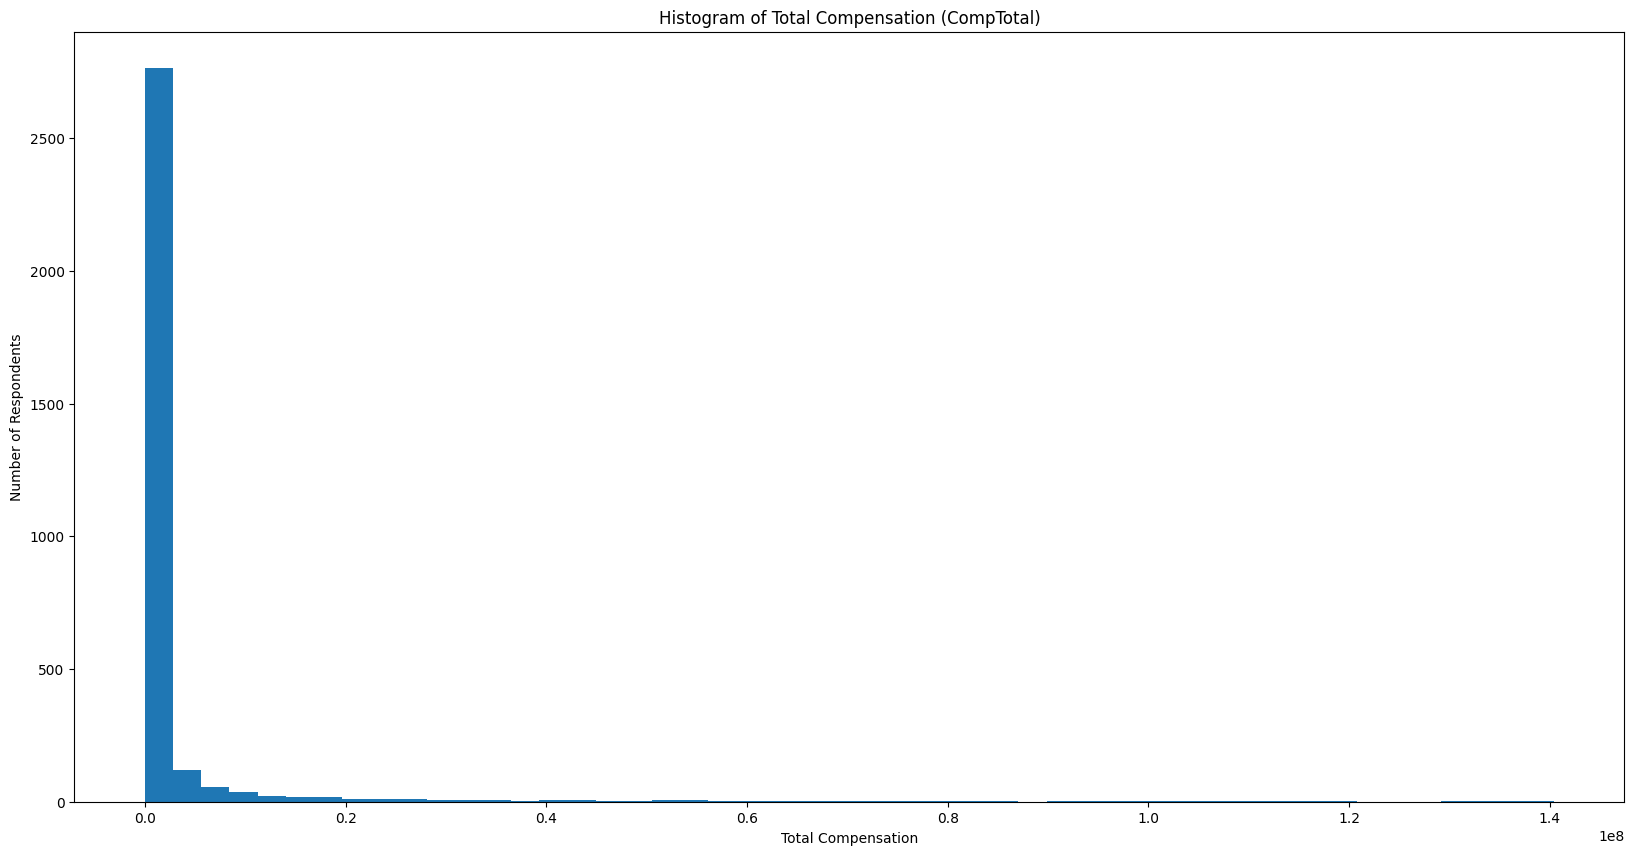

In [52]:
# Convert to numeric
df["CompTotal"] = pd.to_numeric(df["CompTotal"], errors="coerce")
# Clean data and handle outliers
df = df.dropna()
df = df[df["CompTotal"] > 0]
df = df[df["CompTotal"] < df["CompTotal"].quantile(0.95)]
# Plot histogram
plt.figure(figsize=(20, 10))
plt.hist(df['CompTotal'], bins=50)

# Labels and title
plt.title('Histogram of Total Compensation (CompTotal)')
plt.xlabel('Total Compensation')
plt.ylabel('Number of Respondents')
plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


In [62]:
## Write your code here
QUERYY = """
SELECT 
ResponseId,
CASE WHEN YearsCodePro = 'Less than 1 year' THEN 0
        WHEN YearsCodePro = 'More than 50 years' THEN 70
        else YearsCodePro
        end as YearsCodePro FROM main where YearsCodePro is not null
"""
df = pd.read_sql_query(QUERYY, conn)
print(df)

       ResponseId YearsCodePro
0               2           17
1               3           27
2               7            7
3              10           11
4              12           25
...           ...          ...
51605       65429            7
51606       65432           24
51607       65433            3
51608       65435            5
51609       65436            2

[51610 rows x 2 columns]


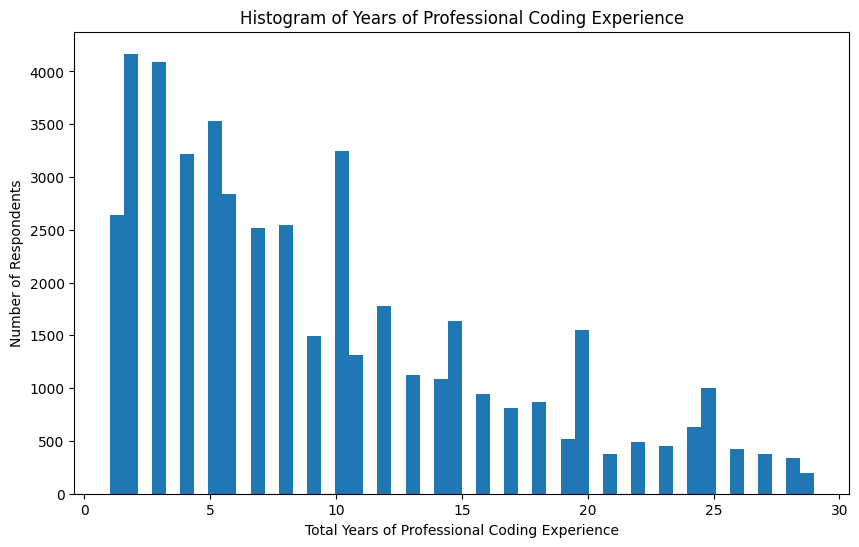

In [64]:
# Convert to numeric
df["YearsCodePro"] = pd.to_numeric(df["YearsCodePro"], errors="coerce")
# Clean data and handle outliers
df = df.dropna()
df = df[df["YearsCodePro"] > 0]
df = df[df["YearsCodePro"] < df["YearsCodePro"].quantile(0.95)]
# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(df['YearsCodePro'], bins=50)

# Labels and title
plt.title('Histogram of Years of Professional Coding Experience')
plt.xlabel('Total Years of Professional Coding Experience')
plt.ylabel('Number of Respondents')

plt.show()


### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


In [53]:
QUERYAge = """
SELECT
    CompTotal,
    CASE
        WHEN Age = 'Under 18 years old' THEN '15'
        WHEN Age = '18-24 years old' THEN '18-24'
        WHEN Age = '25-34 years old' THEN '25-34'
        WHEN Age = '35-44 years old' THEN '35-44'
        WHEN Age = '45-54 years old' THEN '45-54'
        WHEN Age = '55-64 years old' THEN '55-64'
        WHEN Age = '65 years or older' THEN '65+'
        ELSE NULL
    END AS AgeGroup
FROM main
WHERE Age IS NOT NULL
  AND Age != 'Prefer not to say'
  AND CompTotal IS NOT NULL
"""
df = pd.read_sql_query(QUERYAge, conn)
print(df)

       CompTotal AgeGroup
0      2040000.0    18-24
1        28000.0    25-34
2        85000.0    35-44
3        50000.0    35-44
4       110000.0    25-34
...          ...      ...
33721    36000.0    18-24
33722    40000.0    25-34
33723    61000.0    25-34
33724    58000.0    35-44
33725    55000.0    45-54

[33726 rows x 2 columns]


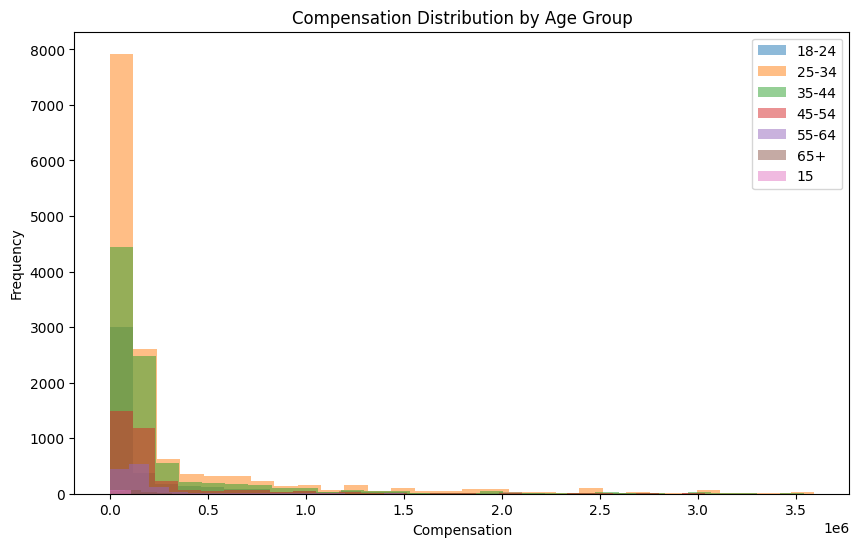

In [55]:
## Write your code here

# Get unique age groups
age_groups = df['AgeGroup'].dropna().unique()

plt.figure(figsize=(10, 6))

# Loop through each age group
for group in age_groups:
    subset = df[df['AgeGroup'] == group]
    plt.hist(subset['CompTotal'], bins=30, alpha=0.5, label=group)

plt.title("Compensation Distribution by Age Group")
plt.xlabel("Compensation")
plt.ylabel("Frequency")
plt.legend()

plt.show()



**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


In [56]:
## Write your code here
QUERYTime = """
SELECT
    TimeSearching,
    CASE
        WHEN Age = 'Under 18 years old' THEN 'Under 18'
        WHEN Age = '18-24 years old' THEN '18-24'
        WHEN Age = '25-34 years old' THEN '25-34'
        WHEN Age = '35-44 years old' THEN '35-44'
        WHEN Age = '45-54 years old' THEN '45-54'
        WHEN Age = '55-64 years old' THEN '55-64'
        WHEN Age = '65 years or older' THEN '65+'
        ELSE NULL
    END AS AgeGroup
FROM main
WHERE Age IS NOT NULL
  AND Age != 'Prefer not to say'
  AND TimeSearching IS NOT NULL
"""
df = pd.read_sql_query(QUERYTime, conn)
print(df)

                    TimeSearching AgeGroup
0             30-60 minutes a day    35-44
1             30-60 minutes a day    35-44
2            60-120 minutes a day    45-54
3             15-30 minutes a day    25-34
4      Less than 15 minutes a day    25-34
...                           ...      ...
28858         30-60 minutes a day    18-24
28859        60-120 minutes a day    18-24
28860  Less than 15 minutes a day    25-34
28861         15-30 minutes a day    25-34
28862         15-30 minutes a day    35-44

[28863 rows x 2 columns]


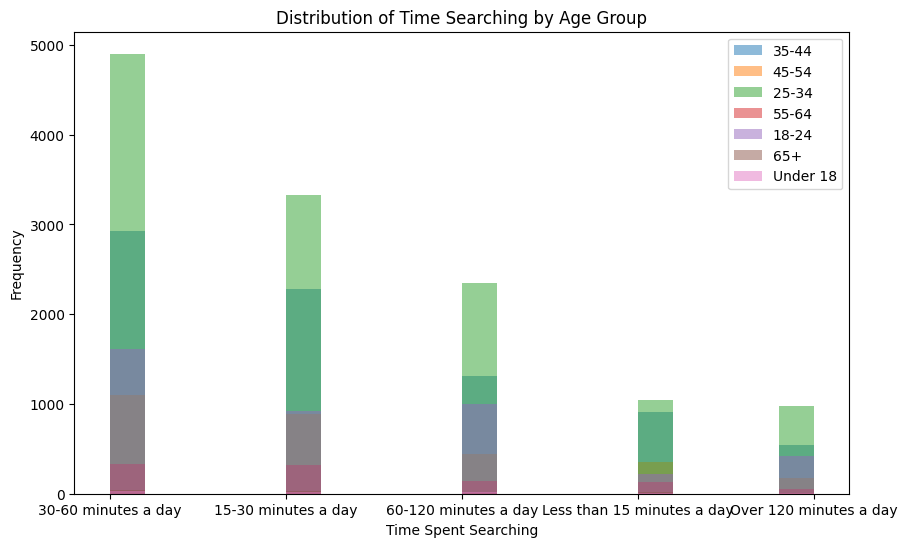

In [58]:
age_groups = df['AgeGroup'].dropna().unique()
plt.figure(figsize=(10, 6))
for group in age_groups:
    subset = df[df['AgeGroup'] == group]
    plt.hist(subset['TimeSearching'], bins=20, alpha=0.5, label=group)

plt.title("Distribution of Time Searching by Age Group")
plt.xlabel("Time Spent Searching")
plt.ylabel("Frequency")
plt.legend()

plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


In [69]:
## Write your code here

QUERYDB = """
SELECT DatabaseWantToWorkWith
FROM main
WHERE DatabaseWantToWorkWith IS NOT NULL
"""

df = pd.read_sql_query(QUERYDB, conn)
# Split into lists
df['DatabaseWantToWorkWith'] = df['DatabaseWantToWorkWith'].str.split(';')
# Expand into separate rows
df = df.explode('DatabaseWantToWorkWith')
top5 = df['DatabaseWantToWorkWith'].value_counts().head(5)
print(top5)

DatabaseWantToWorkWith
PostgreSQL    24005
SQLite        13489
MySQL         12269
MongoDB       10982
Redis         10847
Name: count, dtype: int64


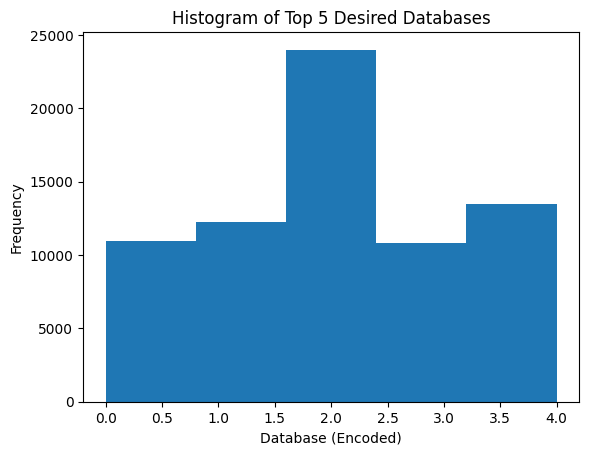

In [75]:
# Filter only top 5 databases
df_top5 = df[df['DatabaseWantToWorkWith'].isin(top5.index)]

codes = df_top5['DatabaseWantToWorkWith'].astype('category').cat.codes

plt.hist(codes, bins=5)

plt.title("Histogram of Top 5 Desired Databases")
plt.xlabel("Database (Encoded)")
plt.ylabel("Frequency")

plt.show()



**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


In [87]:
## Write your code here
QUERYPWL="""
Select
Case when RemoteWork = 'Remote' then 1
when RemoteWork = 'In-person' then 2
when RemoteWork = 'Hybrid (some remote, some in-person)' then 3
Else 0
End as RemoteWork
from main 
where RemoteWork is not null
"""

df = pd.read_sql_query(QUERYPWL, conn)
print(df)

       RemoteWork
0               1
1               1
2               1
3               1
4               2
...           ...
54801           3
54802           1
54803           1
54804           2
54805           3

[54806 rows x 1 columns]


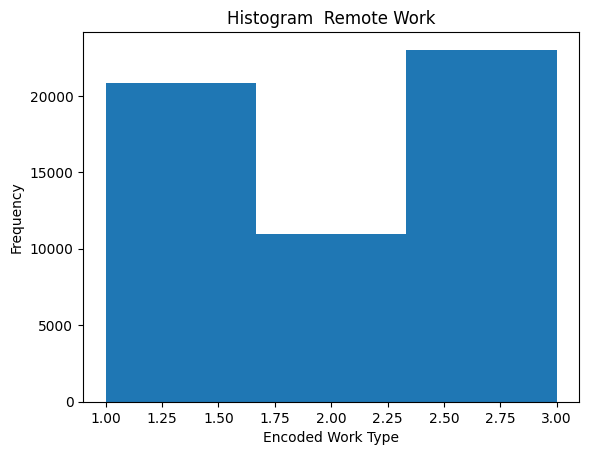

In [88]:
plt.hist(df['RemoteWork'], bins=3)
plt.title('Histogram  Remote Work')
plt.xlabel('Encoded Work Type')
plt.ylabel('Frequency')

plt.show()


### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


In [92]:
## Write your code here
QUERY = """
SELECT CompTotal,
CASE
        WHEN Age = '45-54 years old' THEN '45-54'
        WHEN Age = '55-64 years old' THEN '55-64'
        ELSE NULL
    END AS AgeGroup
FROM main
WHERE Age IN ('45-54 years old', '55-64 years old')
  AND CompTotal IS NOT NULL
"""
df = pd.read_sql_query(QUERY, conn)
print(df)

      CompTotal AgeGroup
0       95000.0    45-54
1      195000.0    45-54
2       54000.0    55-64
3      145000.0    45-54
4       80000.0    55-64
...         ...      ...
4790    40000.0    45-54
4791   250000.0    45-54
4792   250000.0    45-54
4793   157000.0    45-54
4794    55000.0    45-54

[4795 rows x 2 columns]


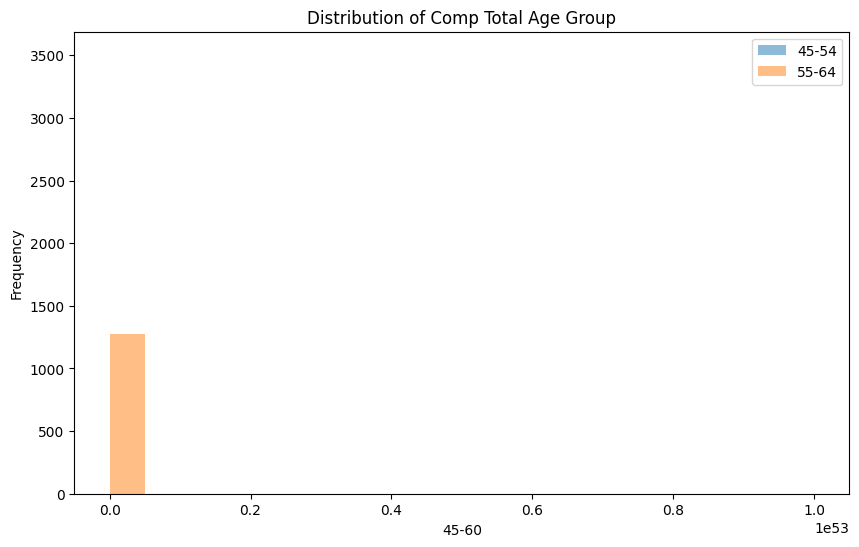

In [94]:

# Convert to numeric
df["CompTotal"] = pd.to_numeric(df["CompTotal"], errors="coerce")
age_groups = df['AgeGroup'].dropna().unique()
plt.figure(figsize=(10, 6))
for group in age_groups:
    subset = df[df['AgeGroup'] == group]
    plt.hist(subset['CompTotal'], bins=20, alpha=0.5, label=group)

plt.title("Distribution of Comp Total Age Group")
plt.xlabel("45-60")
plt.ylabel("Frequency")
plt.legend()

plt.show()



**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


In [98]:
## Write your code here
QUERYJS = """
SELECT JobSat, 
CASE WHEN YearsCodePro = 'Less than 1 year' THEN 0
        WHEN YearsCodePro = 'More than 50 years' THEN 70
        else YearsCodePro
        end as YearsCodePro
FROM main
WHERE JobSat IS NOT NULL
  AND YearsCodePro IS NOT NULL
"""
df = pd.read_sql_query(QUERYJS, conn)
print(df)

       JobSat YearsCodePro
0         8.0           12
1         5.0           27
2        10.0           10
3         6.0            0
4         9.0           18
...       ...          ...
28351     8.0           17
28352     5.0           10
28353     8.0            2
28354     8.0            7
28355     8.0           18

[28356 rows x 2 columns]


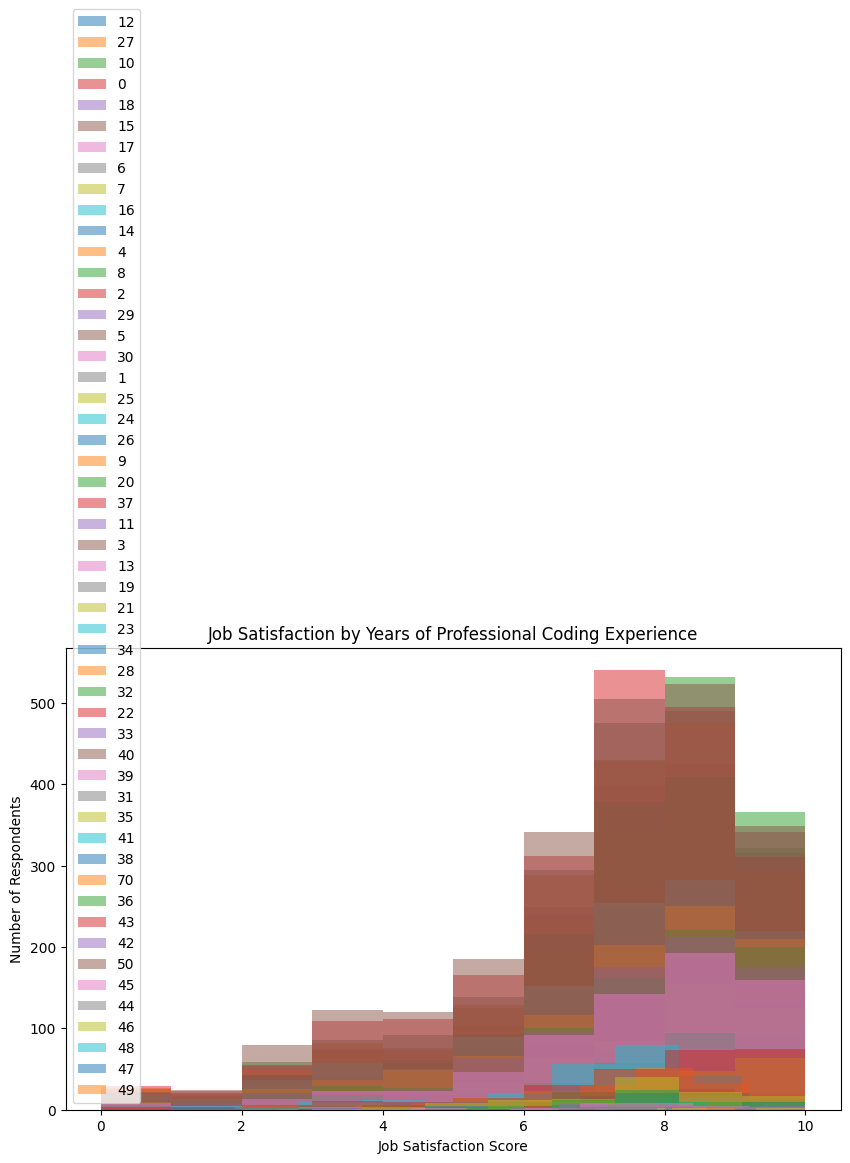

In [100]:
df = df.dropna(subset=["JobSat", "YearsCodePro"])
groups = df['YearsCodePro'].unique()
plt.figure(figsize=(10, 6))
for g in groups:
    subset = df[df['YearsCodePro'] == g]
    plt.hist(subset['JobSat'], bins=10, alpha=0.5, label=g)
plt.title("Job Satisfaction by Years of Professional Coding Experience")
plt.xlabel("Job Satisfaction Score")
plt.ylabel("Number of Respondents")

plt.legend()
plt.show()


### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [101]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
